# 4. Variable Stars

In this notebook tutorial we show how you can inject variable sources into your pixel image simulations. We will first the simplest case of doing this for a single (target) star, and next for a small subfield with three stars. To create realistic variable source files we recommend to have a look at PlatoSim's built-in simulations tool called `varsim` presented in the last section.

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# We use the default input YAML file and configure is later
outputDir = os.getcwd()

---
## 4.1 -  Include a variable source for a target star
---

We here show the simplest example on how to include stellar variability for a single target star. First let's create an instance of our simulation class:

In [4]:
# Set up a Simulation object
sim = Simulation("output_example1", outputDir=outputDir)

To visually make the effect of variability clear we here generate a synthetic sinusoidal signal with an amplitude of several orders of magnitude on (very unrealistic) short time scale: 

In [5]:
# Simple model of variable source
A, P = 2, 10000
time = np.arange(0, P, 25) 
dmag = A * np.cos(2*np.pi * (time/P))

<IPython.core.display.Javascript object>


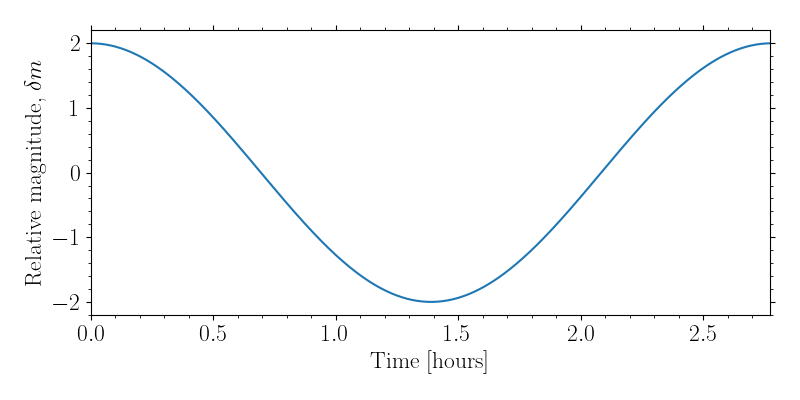

In [6]:
# Show plot of variable source
plt.figure(figsize=(8,4))
thour = time/3600
plt.plot(thour, dmag)
plt.xlim(thour[0], thour[-1])
plt.xlabel('Time [hours]')
plt.ylabel(r'Relative magnitude, $\delta m$')
plt.tight_layout();

We can now use `sim.createVariableSourceFile()` to create an ascii file that PlatoSim can read:

In [7]:
# Automatic catalogue file creation
variableSourceFile = outputDir + "/varsource_example1.txt"
sim.createVariableSourceFile(time, dmag, variableSourceFile)

Assume now we just want to simulate a image time series of a single target star and inject the newly created variability for this star. Then we can use `sim.createVariableSourceList()` to create the ascii file that tell PlatoSim which star a given variable source file should be associated with. Hence:

In [8]:
# Automatic catalogue file creation
starID = [1]
variableSourceList = outputDir + "/varlist_example1.txt"
sim.createVariableSourceList(starID,  [variableSourceFile], variableSourceList)

Again, just like for the creation of the star catalogue file, while using `sim.createVariableSourceList()` the the inclusion of variable sources is activated and the variable source file is automatically set in the YAML tree. If you need to change these simply use:

In [9]:
sim["Sky/IncludeVariableSources"] = True
sim["Sky/VariableSourceList"]     = variableSourceList

We now use the methodlogy from the previous notebook to place a star in the CCD focal plane and create a star catalogue file:

In [10]:
# Select subfield size and location
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([4.0]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([11.0])

# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_example1.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

We can now run simulation of the number of exposures that covers one variable period:

In [11]:
sim["ObservingParameters/NumExposures"] = int(P/25.)

In [12]:
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


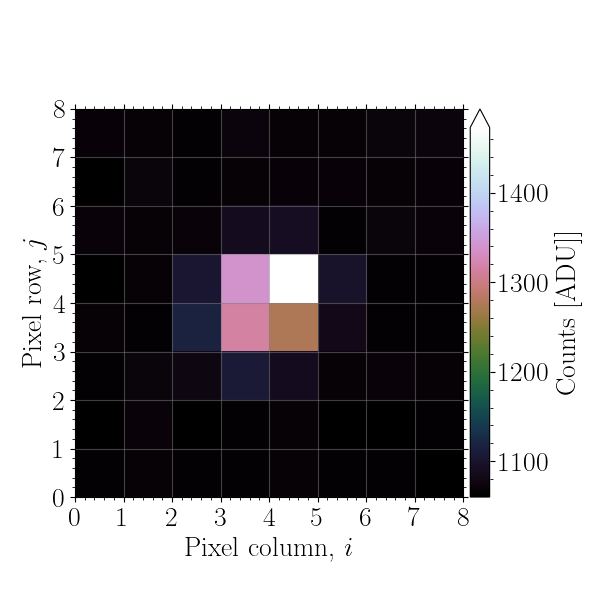

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=399), Output())…

In [13]:
fig, ax = simfile.showImage(imgScale="percentile", clip=1, fontSize=20, 
                            figsize=(6,6), colorBar=True, showGrid=True);

Draw the slider from side to side to see the impact of variability.

---
## 4.2 - Variability of both target and contamint stars
---

In this example we show you can inject a variable signal into both your target star and the stellar contaminants surrounding it. For simplicity we simulate a small subfield of a single target contaminated by two fainter stars. First we fetch the simulation object:

In [14]:
# Set up a Simulation object
sim = Simulation("output_example2", outputDir=outputDir)

We now load three pre-exisiting variable source files. The target is $\gamma$ Doradus star with g-mode pulsations, the first contaminant star is a Eclipsing Binary (EB) system of the Algol type, and the second contaminant star is a Ap type star which shows rotational modulations due to chemical percularities on their surface. 

We here use the function `downloadFrom FTP()` to download the three light curves from our FTP site:

In [15]:
# Download files from KUL FTP site:
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
ut.downloadFromFTP(filename="varsource_gdor.txt",  outputDir=inputDir, server='plato')
ut.downloadFromFTP(filename="varsource_algol.txt", outputDir=inputDir, server='plato')
ut.downloadFromFTP(filename="varsource_ap.txt",    outputDir=inputDir, server='plato')

Let's load and show the light curves: 

<IPython.core.display.Javascript object>


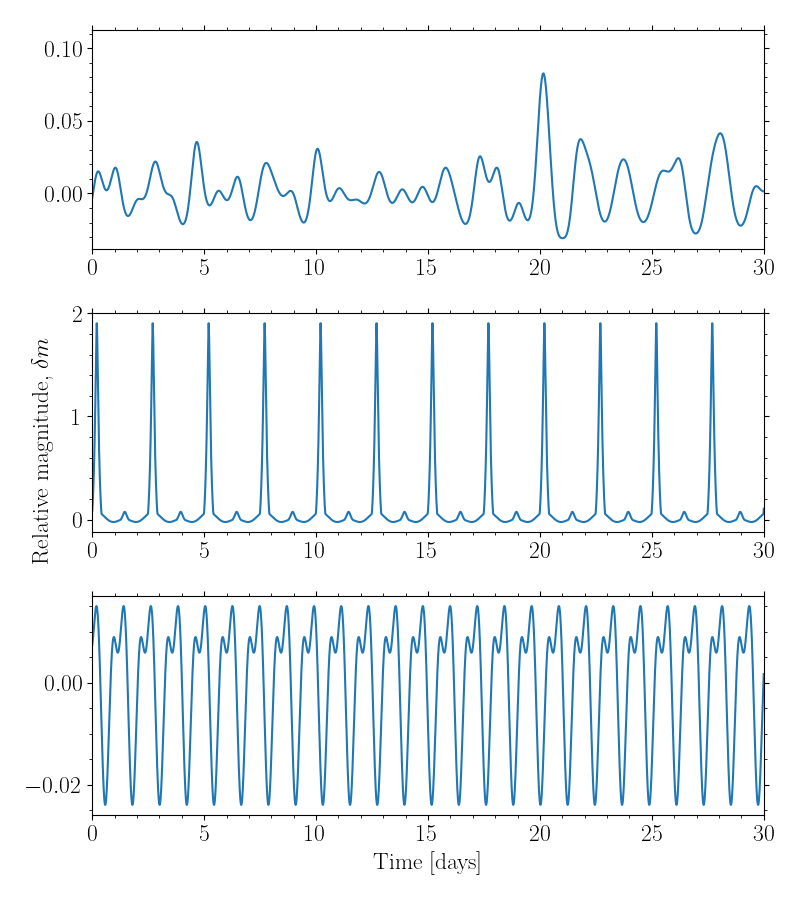

In [16]:
# Load variable source files
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFile2 = inputDir + "/varsource_ap.txt"

# Load files
var0 = np.loadtxt(variableSourceFile0)
var1 = np.loadtxt(variableSourceFile1)
var2 = np.loadtxt(variableSourceFile2)

# Show noise-less light curves
fig, ax = plt.subplots(3, 1, figsize=(8,9))
for i, var in zip(range(3), [var0, var1, var2]):
    time = var[:,0]/86400
    ax[i].plot(time, var[:,1])
    ax[i].set_xlim(time[0], 30)
fig.text(0.04, 0.5, 'Relative magnitude, $\delta m$', va='center', rotation='vertical')
ax[2].set_xlabel('Time [days]')
plt.tight_layout()

We now add these files to the variable source list:

In [17]:
# Automatic catalogue file creation
starID = [0, 1, 2]
variableSourceFiles = [variableSourceFile0, variableSourceFile1, variableSourceFile2]
variableSourceList  = outputDir + "/varlist_example2.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

Just like before we can now create a stellar catalogue that suits our variable setup. We here place the algol type variable a bit further from the target (since it has a bg impact on the photometry with its peak-to-peak amplitude of 2 mag). 

In [18]:
# Select subfield size and location
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([4.0, 3.1, 5.3]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0, 2.8, 6.2]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0, 12.0, 11.0])

# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_example2.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

First, let's check that the stars are placed well within the subfield. Note that you can show distinguish between the target and contaminants when plotting the stellar positions. This can be done using the flag `showStarPositions='PIC'` which will scale the magnitude of the stellar contaminants relative to the target star's filled marker area:

<IPython.core.display.Javascript object>


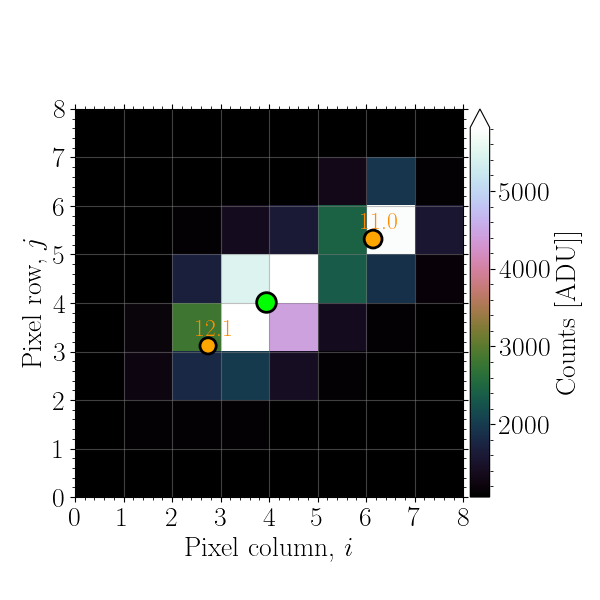

In [19]:
sim["ObservingParameters/NumExposures"] = 1
simfile = sim.run(removeOutputFile=True)
fig, ax = simfile.showImage(imgScale="percentile", clip=3, fontSize=20, 
                            figsize=(6,6), showStarPositions='PIC',
                            colorBar=True, showGrid=True);

You can run the simulation for e.g. 30 days using the `sim.run()` method as shown above. In the next notebook we show how you can extract the photometry of a target star that is contaminated by other variable sources, excactly like this example.

---
## 4.3 - Generate noise-less light curves
---

A suite of software tools exist today to help generating noise-less light curves of variable sources. To help you generating variable source files that can be used directly as input for PlatoSim, you can use the script `varsim` which can be called from the command line:

    varsim -h
    
How to use this script is presented in our [Online Documentation](http://ivs-kuleuven.github.io/PlatoSim3/platonium_tutorials.html). The script `varsim` can be used to generate noise-less light curves of the following variable phenomenons:

- **Solar-like stars**:
    - Ganulations noise
    - Stochastic oscillations (p modes)
    - Spot modulations
    - Flares
- **Pulsating stars**:
    - g-mode pulsations (gamma Doradus)
    - p-mode pulsations (delta Scuti) 
- **Phase curve variations**:
    - Exoplanet transit
    - Exoplanet occulation
    - Relativitic Doppler beaming (Exoplanets & Binaries)
- **Transient phenomenon**:
    - SMBH binary (simple model)